<a href="https://colab.research.google.com/github/NehaBongarde2004/Deep-Learning/blob/main/DL_Exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training RNN model...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - accuracy: 0.6980 - loss: 0.5630 - val_accuracy: 0.7416 - val_loss: 0.5126
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 96ms/step - accuracy: 0.8466 - loss: 0.3578 - val_accuracy: 0.8336 - val_loss: 0.4132
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.7794 - loss: 0.4641 - val_accuracy: 0.7373 - val_loss: 0.5531

Training LSTM model...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 152s 191ms/step - accuracy: 0.7712 - loss: 0.4846 - val_accuracy: 0.8267 - val_loss: 0.4095
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 172ms/step - accuracy: 0.8183 - loss: 0.3963 - val_accuracy: 0.6998 - val_loss: 0.5716
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 199ms/step - accuracy: 0.8536 - loss: 0.3414 - val_accuracy: 0.8669 - val_loss: 0.3143

Training GRU model...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 155s 194ms/step - accuracy: 0.7763 - loss: 0.4544 - val_accuracy: 0.8686 - val_loss: 0.3145
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 152s 194ms/st

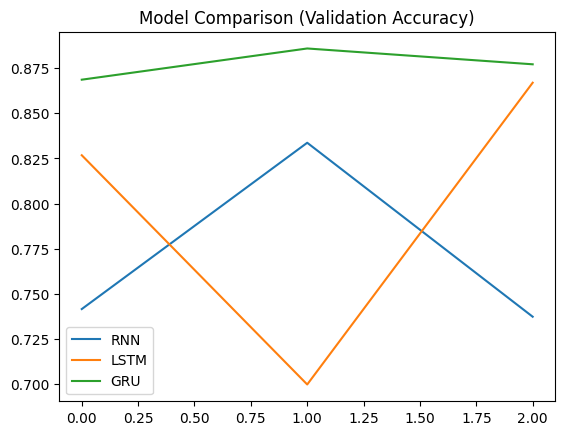

In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load IMDb dataset
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

# Pad sequences
x_train = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

# Function to build model
def build_model(model_type):
    model = models.Sequential()
    model.add(layers.Embedding(vocab_size, 128, input_length=max_len))

    if model_type == "RNN":
        model.add(layers.SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(layers.LSTM(64))
    elif model_type == "GRU":
        model.add(layers.GRU(64))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Train models
histories = {}
models_dict = {}

for m in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {m} model...")
    model = build_model(m)
    history = model.fit(x_train, y_train, epochs=3,
                        validation_data=(x_test, y_test))
    histories[m] = history
    models_dict[m] = model

# Evaluate models
for m in models_dict:
    loss, acc = models_dict[m].evaluate(x_test, y_test)
    print(f"{m} Test Accuracy: {acc}")

# Plot Learning Curves
for m in histories:
    plt.plot(histories[m].history['val_accuracy'], label=m)

plt.legend()
plt.title("Model Comparison (Validation Accuracy)")
plt.show()